In [55]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

In [34]:
trash_data = gpd.read_file('./data/trash_hauler_report.csv')
nashville = gpd.read_file('./data/nashville_zip_codes.geojson')
trash_data

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,25270,11/01/17,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207,RED RIVER,3205,2,1727970.41206786,686779.478088711
1,25274,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218,RED RIVER,4202,1,1721259.36568104,685444.799565154
2,25276,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209,RED RIVER,4205,20,1707026.75348931,659887.471571312
3,25307,11/01/17,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207,WASTE IND,2206,2,1735691.77097349,685027.245922773
4,25312,11/01/17,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209,RED RIVER,4203,20,1710185.77229504,664205.101065545
...,...,...,...,...,...,...,...,...,...,...,...
20221,267125,11/01/19,Trash - Curbside/Alley Missed Pickup,MISSED...NEIGHBORS MISSED,2731 Murfreesboro Pike,37013,RED RIVER,4502,32,1781137.26293528,632448.551143857
20222,267126,11/01/19,Trash - Curbside/Alley Missed Pickup,entire alley,"1621 Long Ave, Nashville, TN 37206, United States",37206,METRO,9508,6,1749711.39882271,669201.601569129
20223,267130,11/01/19,Trash - Curbside/Alley Missed Pickup,missed several,"2943 Windemere Cir, Nashville, TN 37214, Unite...",37214,RED RIVER,1502,15,1770293.38813099,674936.303809043
20224,267134,11/01/19,Trash - Curbside/Alley Missed Pickup,Caller stated trash was missed & were only pic...,"3325 Murfreesboro Pike, Nashville, TN 37013, U...",37013,RED RIVER,4502,32,1785224.99799806,627146.400187231


In [6]:
# Finding unique values for the Request column 
pd.unique(trash_data['Request'])

array(['Trash - Backdoor', 'Trash - Curbside/Alley Missed Pickup',
       'Trash Collection Complaint', 'Damage to Property'], dtype=object)

In [7]:
backdoor = trash_data.loc[trash_data['Request'] == 'Trash - Backdoor']
backdoor.shape

(2629, 11)

In [8]:
cs_alley = trash_data.loc[trash_data['Request'] == 'Trash - Curbside/Alley Missed Pickup']
cs_alley.shape

(15028, 11)

In [9]:
complaint = trash_data.loc[trash_data['Request'] == 'Trash Collection Complaint']
#complaint

In [10]:
contains_miss = complaint['Description'].str.contains('miss', case = 'False', na ='False')
#contains_miss

C:\Users\EpicWork\AppData\Local\Temp\ipykernel_24736\3712832755.py:1: FutureWarning: Allowing a non-bool 'na' in obj.str.contains is deprecated and will raise in a future version.
  contains_miss = complaint['Description'].str.contains('miss', case = 'False', na ='False')


In [11]:
miss_complaint = complaint[contains_miss]
miss_complaint.shape

(453, 11)

In [12]:
miss_all = pd.concat([backdoor, cs_alley, miss_complaint], ignore_index = 'True')

In [13]:
miss_all['Short Address'] = miss_all['Incident Address'].str.split(',', n=1).str[0]
miss_all['Short Address'] = miss_all['Short Address'].str.lower()
miss_all

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y,Short Address
0,25270,11/01/17,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207,RED RIVER,3205,2,1727970.41206786,686779.478088711,3817 crouch dr
1,25692,11/02/17,Trash - Backdoor,Backdoor/miss for last Friday. Does not unders...,3041 Fieldstone Dr,37013,RED RIVER,3504,29,1785677.15882833,633139.246264943,3041 fieldstone dr
2,25775,11/02/17,Trash - Backdoor,Missed trash pickup said has been picking up b...,4625 long br,37013,RED RIVER,4505,28,1770350.41605229,634143.871818357,4625 long br
3,25802,11/02/17,Trash - Backdoor,Missed.,4828 Cimarron Way,37013,RED RIVER,3404,30,1766186.56409375,629785.602877192,4828 cimarron way
4,25858,11/03/17,Trash - Backdoor,Missed- she said her grandson was over yesterd...,2005 Lebanon Pike,37210,RED RIVER,1504,15,1760561.7630735,665276.001224629,2005 lebanon pike
...,...,...,...,...,...,...,...,...,...,...,...,...
18105,266466,10/31/19,Trash Collection Complaint,"Paid/Backdoor-Trash missed last Thursday, does...","809 Winthorne Ct, Nashville, TN 37217, United ...",37217,RED RIVER,1402,16,1759043.58424902,651549.019214337,809 winthorne ct
18106,266628,10/31/19,Trash Collection Complaint,Disabled caller stated she is keep getting mis...,"1719 Windover Dr, Nashville, TN 37218, United ...",37218,RED RIVER,4202,2,1718308.69339541,680762.907491275,1719 windover dr
18107,266708,11/01/19,Trash Collection Complaint,Caller stated her trash has been missed for 2 ...,"4305 Granny White Pike, Nashville, TN 37204, U...",37204,RED RIVER,3302,25,1731857.80036635,644223.201524295,4305 granny white pike
18108,266710,11/01/19,Trash Collection Complaint,"Trash/has been missed for weeks in a row, curb...","3325 Murfreesboro Pike, Nashville, TN 37013, U...",37013,RED RIVER,4502,32,1785224.99799806,627146.400187231,3325 murfreesboro pike


In [14]:
miss_count_by_address = miss_all['Short Address'].value_counts().reset_index(name='Missed Pickups')
#miss_count_by_address = miss_count_by_address.to_frame()
miss_count_by_address

,Short Address,Missed Pickups
0,110 george l davis blvd,27
1,12546 old hickory blvd,21
2,5135 hickory hollow pkwy,20
3,802 crescent rd,19
4,1584 bell rd,19
...,...,...
11305,739 rodney dr,1
11306,3805 elkins ave,1
11307,800 old hickory blvd,1
11308,631 blackstone ave,1


In [15]:
frequently_missed = miss_count_by_address.loc[miss_count_by_address['Missed Pickups'] > 1]
frequently_missed

,Short Address,Missed Pickups
0,110 george l davis blvd,27
1,12546 old hickory blvd,21
2,5135 hickory hollow pkwy,20
3,802 crescent rd,19
4,1584 bell rd,19
...,...,...
3362,321 charmaine ct,2
3363,2243 foster ave,2
3364,120 islandia dr,2
3365,89 riverpoint pass,2


In [16]:
frequently_missed['Fine Amount'] = (frequently_missed['Missed Pickups'] - 1) * 200
frequently_missed

C:\Users\EpicWork\AppData\Local\Temp\ipykernel_24736\825867008.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  frequently_missed['Fine Amount'] = (frequently_missed['Missed Pickups'] - 1) * 200


,Short Address,Missed Pickups,Fine Amount
0,110 george l davis blvd,27,5200
1,12546 old hickory blvd,21,4000
2,5135 hickory hollow pkwy,20,3800
3,802 crescent rd,19,3600
4,1584 bell rd,19,3600
...,...,...,...
3362,321 charmaine ct,2,200
3363,2243 foster ave,2,200
3364,120 islandia dr,2,200
3365,89 riverpoint pass,2,200


In [17]:
total_damages = frequently_missed['Fine Amount'].sum()
def currency_format(amount):
    return "${:,}".format(amount)
formatted_cost = currency_format(total_damages)
print(f"The total amount in damages is {formatted_cost}")

The total amount in damages is $1,360,000


<h1>Other types of complaints</h1>

In [90]:
other_complaints = trash_data[~trash_data['Request Number'].isin(miss_all['Request Number'])].reset_index()
#other_complaints

<h1>Heat Maps</h1>

<h2>Missed Pick Ups</h2>

In [72]:
miss_by_zip = miss_all['Request Number'].groupby(miss_all['Zip Code']).count().reset_index()
#miss_by_zip

In [46]:
nashville.columns

Index(['OBJECTID', 'ZipCode', 'POName', 'GlobalID', 'geometry'], dtype='object')

In [71]:
miss_map = nashville.merge(miss_by_zip, how = 'left', left_on = 'ZipCode', right_on = 'Zip Code')
#miss_map

In [ ]:
miss_map.plot(column = 'Request Number', 
              cmap = 'OrRd', 
              legend = True, 
              #scheme = "quantiles",
              figsize = (12, 12),
              legend_kwds={"label": "Number of Missed Pickups", "orientation": "horizontal"},
             missing_kwds = {"color": "lightgrey", "edgecolor": "yellow", "hatch": "///"})
fig = plt.gcf()
#fig.set_size_inches(12, 12)
plt.show()
#nashville.plot()

<h2>Total Fines</h2>

In [96]:
fine_by_zip = frequently_missed.merge(miss_all, how = 'left', on = 'Short Address')
fine_by_zip

,Short Address,Missed Pickups,Fine Amount,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,110 george l davis blvd,27,5200,55760,03/23/18,Trash - Curbside/Alley Missed Pickup,missed all the time - said no alley access {ca...,110 George L Davis Blvd,37203,METRO,9407,19,1735554.15555721,664658.933250031
1,110 george l davis blvd,27,5200,71125,05/30/18,Trash - Curbside/Alley Missed Pickup,trash is full needs pick up. Matt stated that ...,110 George L Davis Blvd,37203,METRO,9407,19,1735555.53424545,664657.700582383
2,110 george l davis blvd,27,5200,73434,06/07/18,Trash - Curbside/Alley Missed Pickup,Missed. Caller states that this is a business ...,110 George L Davis Blvd,37203,METRO,9407,19,1735554.15555721,664658.933250031
3,110 george l davis blvd,27,5200,77172,06/21/18,Trash - Curbside/Alley Missed Pickup,trash is full needs pick up. Matt stated that ...,110 George L Davis Blvd,37203,METRO,9407,19,1735554.15555721,664658.933250031
4,110 george l davis blvd,27,5200,82908,07/13/18,Trash - Curbside/Alley Missed Pickup,Missed. Caller states that this is a business ...,110 George L Davis Blvd,37203,METRO,9407,19,1735554.15555721,664658.933250031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10162,120 islandia dr,2,200,77805,06/25/18,Trash - Curbside/Alley Missed Pickup,Curbside trash miss last Friday. 1 cart out.,120 Islandia Dr,37217,RED RIVER,3501,29,1787179.12234282,642486.52788852
10163,89 riverpoint pass,2,200,133899,01/23/19,Trash - Curbside/Alley Missed Pickup,missed... others in area missed,"89 Riverpoint Pass, Nashville, TN 37214, Unite...",37214,RED RIVER,1503,15,1773181.83083379,669295.671730352
10164,89 riverpoint pass,2,200,240712,08/31/19,Trash - Curbside/Alley Missed Pickup,My garbage was not picked up yesterday. I hav...,"89 Riverpoint Pass, Nashville, TN 37214, Unite...",37214,RED RIVER,1503,15,1773181.83083379,669295.671730352
10165,115 rosa l parks blvd,2,200,25864,11/03/17,Trash Collection Complaint,missed pick up - please call (615) 519-3192 wa...,115 Rosa L Parks BLvd,37203,,,19,1737457.7654246,665597.600905288


In [94]:
fine_map = nashville.merge(fine_by_zip, how = 'left', left_on = 'ZipCode', right_on = 'Zip Code')
fine_map = fine_map.groupby('ZipCode').sum('Fine Amount').reset_index()
fine_map

,ZipCode,OBJECTID,Missed Pickups,Fine Amount
0,37013,550724,5315.0,828600.0
1,37015,497,0.0,0.0
2,37027,364397,3339.0,529200.0
3,37064,246,0.0,0.0
4,37072,822,0.0,0.0
5,37076,2244,0.0,0.0
6,37080,530,0.0,0.0
7,37086,699,4.0,400.0
8,37115,251671,2727.0,414400.0
9,37122,537,0.0,0.0


AttributeError: Line2D.set() got an unexpected keyword argument 'legend_kwds'

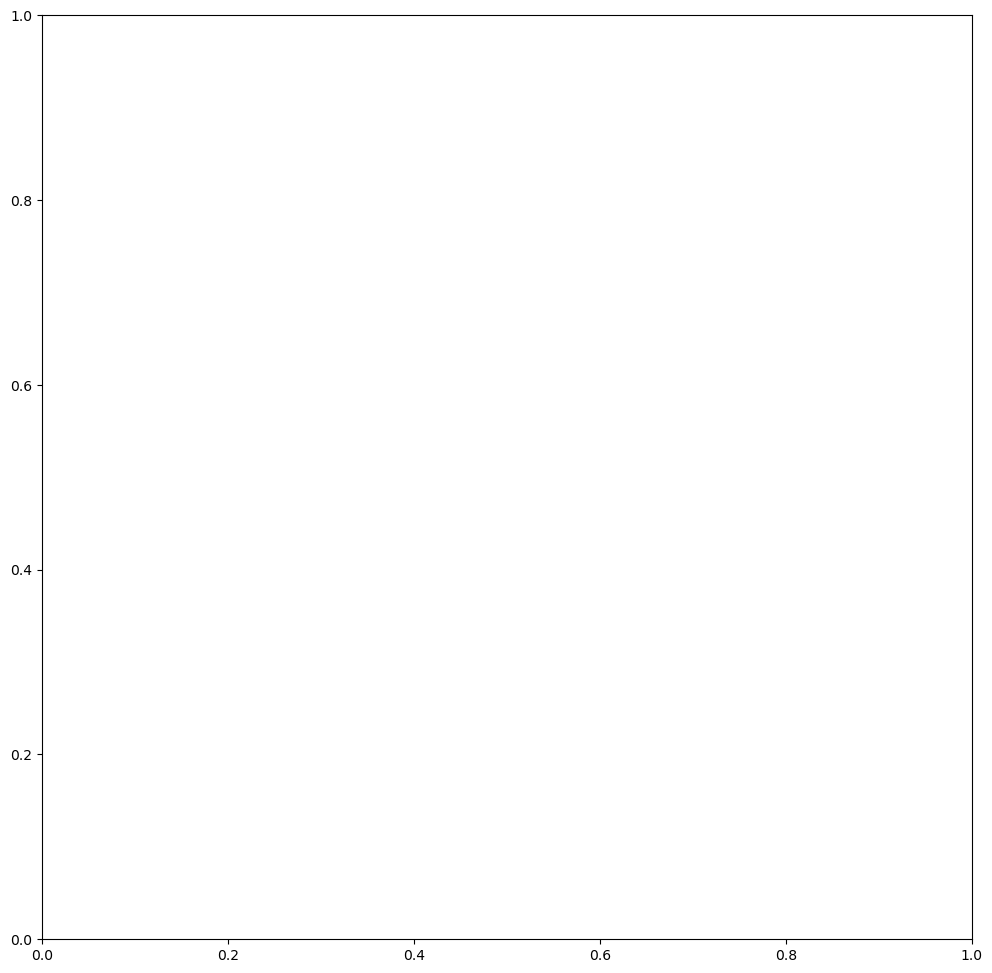

In [88]:
fine_map.plot(column = 'Fine Amount', 
              cmap = 'OrRd', 
              legend = True, 
              #scheme = "quantiles",
              figsize = (12, 12),
              legend_kwds={"label": "Number of Missed Pickups", "orientation": "horizontal"},
             missing_kwds = {"color": "lightgrey", "edgecolor": "yellow", "hatch": "///"})
fig = plt.gcf()
plt.show()

<h1>Investigating metro crews vs contractor performance</h1>

<h2>Metro Performance</h2>

In [19]:
metro = miss_all.loc[miss_all['Trash Hauler'].str.lower() == 'metro'].reset_index()
#metro

In [20]:
metro_miss_count = metro['Short Address'].value_counts().reset_index(name='Missed Pickups')

In [21]:
metro_freq_miss = metro_miss_count.loc[metro_miss_count['Missed Pickups'] > 1]
metro_freq_miss['Fine Amount'] = (metro_freq_miss['Missed Pickups'] - 1) * 200
metro_freq_miss

C:\Users\EpicWork\AppData\Local\Temp\ipykernel_24736\196924443.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metro_freq_miss['Fine Amount'] = (metro_freq_miss['Missed Pickups'] - 1) * 200


,Short Address,Missed Pickups,Fine Amount
0,1816 jo johnston ave,18,3400
1,110 george l davis blvd,17,3200
2,2813 delaware ave,12,2200
3,2801 delaware ave,11,2000
4,2415 brasher ave,10,1800
...,...,...,...
551,836 cherokee ave,2,200
552,913 west ave,2,200
553,1609 lillian st,2,200
554,1922 ed temple blvd,2,200


In [22]:
metro_damages = metro_freq_miss['Fine Amount'].sum()
metro_format = currency_format(metro_damages)
metro_format

'$215,800'

<h2>Red River Performance</h2>

In [23]:
trash_data['Trash Hauler'].unique()

array(['RED RIVER', 'WASTE IND', 'METRO', '', 'Metro'], dtype=object)

In [24]:
red_river = miss_all.loc[miss_all['Trash Hauler'] == 'RED RIVER'].reset_index()
#red_river

In [25]:
red_river_miss_count = red_river['Short Address'].value_counts().reset_index(name='Missed Pickups')

In [26]:
red_river_freq_miss = red_river_miss_count.loc[red_river_miss_count['Missed Pickups'] > 1]
red_river_freq_miss['Fine Amount'] = (red_river_freq_miss['Missed Pickups'] - 1) * 200
red_river_freq_miss

C:\Users\EpicWork\AppData\Local\Temp\ipykernel_24736\2638443975.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  red_river_freq_miss['Fine Amount'] = (red_river_freq_miss['Missed Pickups'] - 1) * 200


,Short Address,Missed Pickups,Fine Amount
0,12546 old hickory blvd,21,4000
1,5135 hickory hollow pkwy,19,3600
2,1584 bell rd,18,3400
3,6007 obrien ave,17,3200
4,802 crescent rd,17,3200
...,...,...,...
2412,468 sunliner dr,2,200
2413,1707 porter rd,2,200
2414,613 may dr,2,200
2415,722 dover rd,2,200


In [27]:
red_river_damages = red_river_freq_miss['Fine Amount'].sum()
red_river_format = currency_format(red_river_damages)
red_river_format

'$970,000'

<h2>Waste Ind Performance</h2>

In [28]:
waste_ind = miss_all.loc[miss_all['Trash Hauler'] == 'WASTE IND'].reset_index()
#waste_ind

In [29]:
waste_ind_miss_count = waste_ind['Short Address'].value_counts().reset_index(name='Missed Pickups')

In [30]:
waste_ind_freq_miss = waste_ind_miss_count.loc[waste_ind_miss_count['Missed Pickups'] > 1]
waste_ind_freq_miss['Fine Amount'] = (waste_ind_freq_miss['Missed Pickups'] - 1) * 200
waste_ind_freq_miss

C:\Users\EpicWork\AppData\Local\Temp\ipykernel_24736\2429048491.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  waste_ind_freq_miss['Fine Amount'] = (waste_ind_freq_miss['Missed Pickups'] - 1) * 200


,Short Address,Missed Pickups,Fine Amount
0,15 hermitage ave,16,3000
1,123 37th ave n,10,1800
2,1011 elm hill pike,10,1800
3,3406 batavia st,10,1800
4,1517 12th ave n,7,1200
...,...,...,...
223,105 evelyn dr,2,200
224,72 lyle ln,2,200
225,34 n hill st,2,200
226,916 32nd ave n,2,200


In [31]:
waste_ind_damages = waste_ind_freq_miss['Fine Amount'].sum()
waste_ind_format = currency_format(waste_ind_damages)
waste_ind_format

'$78,200'

<h1>Finding total missed pickups by route</h1>

In [80]:
miss_by_route = miss_all['Request Number'].groupby(miss_all['Trash Route']).count().reset_index()
miss_by_route.sort_values(by = 'Request Number')

,Trash Route,Request Number
23,1502S,1
60,2505S,2
106,4201S,2
78,3303S,2
135,4504S,3
...,...,...
7,1301,264
10,1303,268
75,3302,300
134,4504,329
